<a href="https://colab.research.google.com/github/vijaygwu/robotics/blob/main/SEAS6520_Ch18_RL_vs_MPC_vs_DP_Energy_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEAS 6520 – Chapter 18 Companion Notebook
## Energy Optimization with Nanogalvanic + Battery Robotics (RL vs MPC vs Dynamic Programming)

This notebook demonstrates how **AI/control** enables **endurance** when a robot has:
- a rechargeable **battery**
- a consumable **nanogalvanic fuel** source (Al + H₂O → H₂ + heat), converted via a **fuel cell**
- a safety constraint (cooldown) representing reaction/pressure/thermal management

We compare three approaches:
1) **RL (tabular Q-learning)** – model-free learning from rollouts  
2) **DP (finite-horizon dynamic programming)** – optimal for a known demand trace  
3) **MPC (receding-horizon planning)** – replans with short lookahead

Edit parameters live (fuel cell power, water availability, cooldown, AI compute bursts).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.random.seed(7)

def clamp(x, lo, hi):
    return max(lo, min(hi, x))


## 1) Parameters (edit live)


In [2]:
T = 180       # minutes
dt_hr = 1/60  # 1 minute in hours

# Battery
E_batt_max = 120.0
E_batt0 = 120.0
eta_batt = 0.95

# Nanogalvanic + fuel cell
m_fuel0 = 60.0
e_fuel_wh_per_g = 8.7
eta_fc = 0.55

P_fc_max = 120.0
P_activation_target = 90.0
cooldown_after_activation = 2

# Load model (mobility + AI compute bursts)
P_base = 45.0
P_move = 35.0
P_ai_burst = 60.0

burst_prob = 0.18
burst_len_mean = 3

# Chapter 18 constraint: water availability uncertainty
water_availability = 1.0  # try 0.8


## 2) Generate demand trace


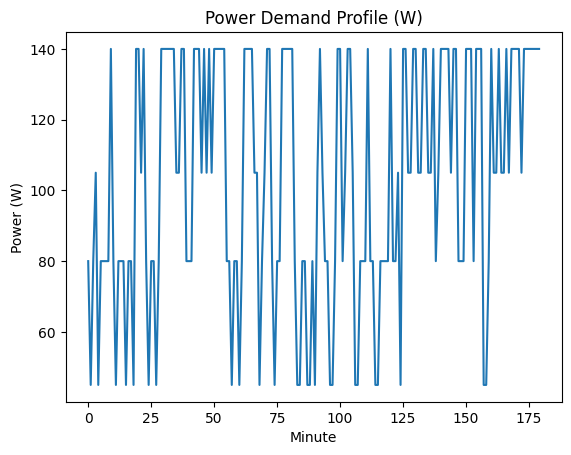

Avg load: 103.5 W
AI burst minutes: 102 out of 180


In [3]:
def sample_ai_bursts(T, burst_prob=0.2, burst_len_mean=3):
    bursts = np.zeros(T, dtype=int)
    t = 0
    while t < T:
        if np.random.rand() < burst_prob:
            L = max(1, int(np.random.exponential(burst_len_mean)))
            bursts[t:min(T, t+L)] = 1
            t += L
        else:
            t += 1
    return bursts


def generate_power_profile(T):
    moving = (np.random.rand(T) < 0.7).astype(int)
    bursts = sample_ai_bursts(T, burst_prob=burst_prob, burst_len_mean=burst_len_mean)
    P = P_base + moving * P_move + bursts * P_ai_burst
    return P, moving, bursts


P_load, moving, bursts = generate_power_profile(T)

plt.figure()
plt.plot(P_load)
plt.title("Power Demand Profile (W)")
plt.xlabel("Minute"); plt.ylabel("Power (W)")
plt.show()

print("Avg load:", round(float(P_load.mean()), 2), "W")
print("AI burst minutes:", int(bursts.sum()), "out of", T)


## 3) Simulator


In [4]:
@dataclass
class SimResult:
    runtime: int
    E_batt_trace: np.ndarray
    m_fuel_trace: np.ndarray
    action_trace: np.ndarray
    unmet_trace: np.ndarray
    batt_wh_used: float
    fuel_wh_used: float


def step_dynamics(E_batt, m_fuel, cooldown, P, a, water_p=1.0):
    if cooldown > 0 and a == 1:
        a = 0

    water_ok = (np.random.rand() < water_p) if a == 1 else True

    P_from_fc = 0.0
    m_used = 0.0
    fuelcell_wh_out = 0.0

    if a == 1 and m_fuel > 0 and water_ok:
        P_from_fc = min(P_activation_target, P_fc_max, P)
        e_elec = P_from_fc * dt_hr
        e_fuel_required = e_elec / max(1e-9, eta_fc)
        m_used = min(e_fuel_required / max(1e-9, e_fuel_wh_per_g), m_fuel)

        e_fuel_actual = m_used * e_fuel_wh_per_g
        e_elec_actual = e_fuel_actual * eta_fc
        P_from_fc = e_elec_actual / dt_hr

        m_fuel -= m_used
        fuelcell_wh_out = e_elec_actual
        cooldown = cooldown_after_activation
    elif a == 1 and not water_ok:
        cooldown = cooldown_after_activation

    P_remaining = max(0.0, P - P_from_fc)
    e_needed = P_remaining * dt_hr
    e_from_batt = e_needed / max(1e-9, eta_batt)

    batt_wh_out = 0.0
    if E_batt >= e_from_batt:
        E_batt -= e_from_batt
        unmet = 0.0
        batt_wh_out = e_needed
    else:
        batt_wh_out = E_batt * eta_batt
        unmet = e_needed - batt_wh_out
        E_batt = 0.0

    cooldown = max(0, cooldown - 1)
    return E_batt, m_fuel, cooldown, unmet, batt_wh_out, fuelcell_wh_out, a


def simulate(P_load, policy_fn, water_p=1.0):
    E_batt, m_fuel, cooldown = E_batt0, m_fuel0, 0
    E_trace, m_trace, a_trace, unmet_trace = [], [], [], []
    batt_wh_used, fuel_wh_used = 0.0, 0.0

    for t in range(len(P_load)):
        P = float(P_load[t])
        a = int(policy_fn(E_batt, m_fuel, cooldown, P, t))

        E_batt, m_fuel, cooldown, unmet, batt_out, fuel_out, a_used = step_dynamics(
            E_batt, m_fuel, cooldown, P, a, water_p=water_p
        )

        E_trace.append(E_batt)
        m_trace.append(m_fuel)
        a_trace.append(a_used)
        unmet_trace.append(unmet)

        batt_wh_used += batt_out
        fuel_wh_used += fuel_out

        if unmet > 1e-9:
            return SimResult(t+1, np.array(E_trace), np.array(m_trace),
                             np.array(a_trace), np.array(unmet_trace),
                             batt_wh_used, fuel_wh_used)

    return SimResult(len(P_load), np.array(E_trace), np.array(m_trace),
                     np.array(a_trace), np.array(unmet_trace),
                     batt_wh_used, fuel_wh_used)


def plot_result(res, title_prefix=""):
    plt.figure(); plt.plot(res.E_batt_trace)
    plt.title(f"{title_prefix} Battery Energy (Wh remaining)")
    plt.xlabel("Minute"); plt.ylabel("Wh"); plt.show()

    plt.figure(); plt.plot(res.m_fuel_trace)
    plt.title(f"{title_prefix} Fuel Mass (g remaining)")
    plt.xlabel("Minute"); plt.ylabel("g"); plt.show()

    plt.figure(); plt.step(np.arange(len(res.action_trace)), res.action_trace, where="post")
    plt.title(f"{title_prefix} Activation Decisions (1=activate)")
    plt.xlabel("Minute"); plt.ylabel("Action"); plt.ylim(-0.1, 1.1); plt.show()


## 4) Baseline heuristic


Baseline runtime: 100 min


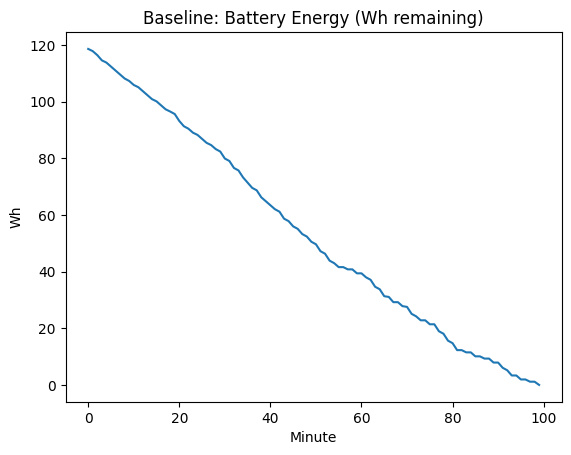

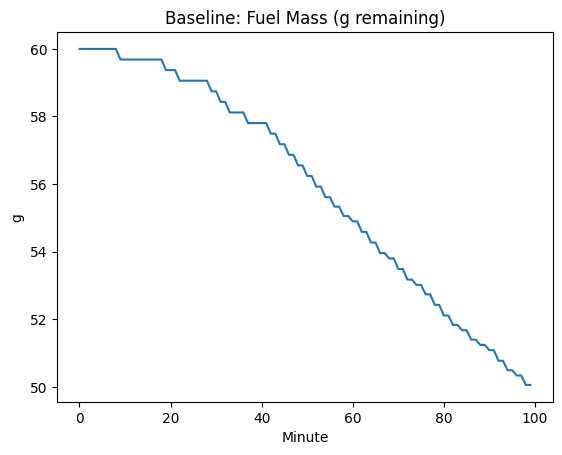

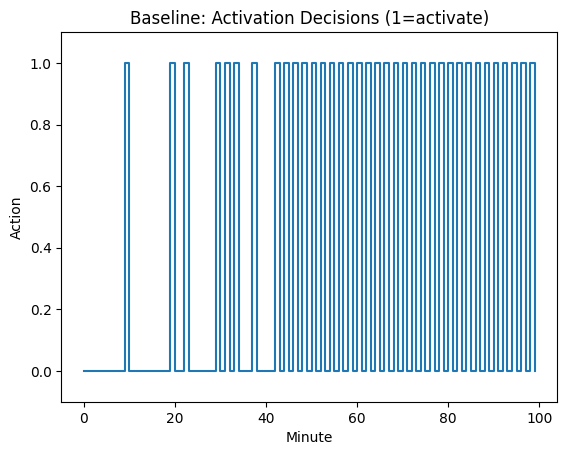

In [5]:
def baseline_policy(E_batt, m_fuel, cooldown, P, t):
    batt_frac = E_batt / E_batt_max
    heavy = P > (P_base + P_move + 0.5 * P_ai_burst)
    if m_fuel > 0 and cooldown == 0 and (batt_frac < 0.35 or heavy):
        return 1
    return 0

res_base = simulate(P_load, baseline_policy, water_p=water_availability)
print("Baseline runtime:", res_base.runtime, "min")
plot_result(res_base, "Baseline:")


## 5) RL: Tabular Q-learning


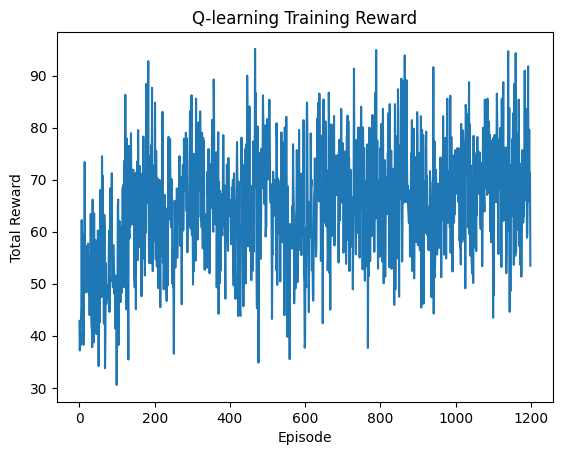

RL runtime: 106 min


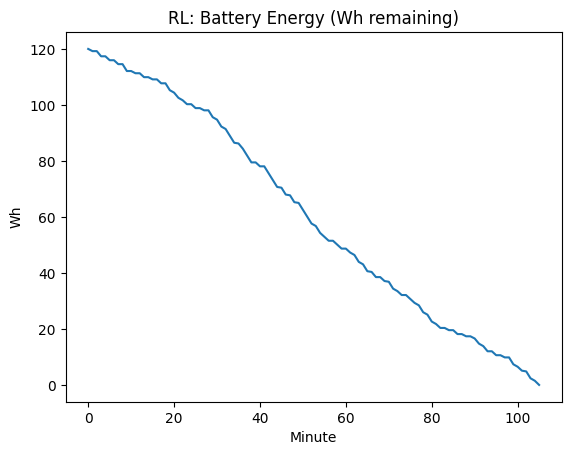

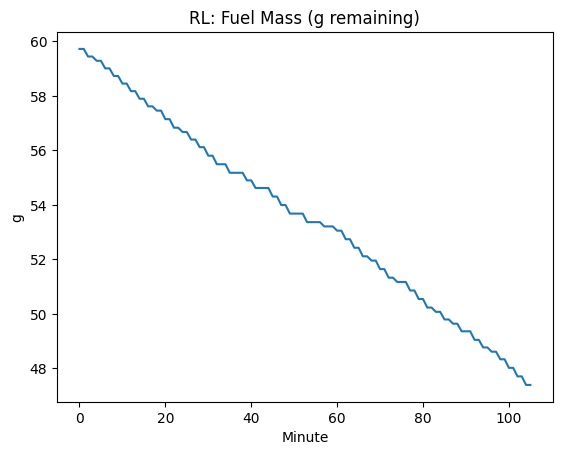

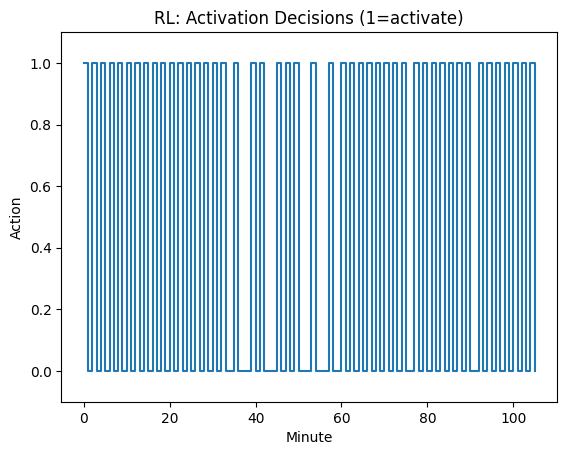

In [6]:
def bin_value(x, bins):
    return int(np.digitize([x], bins)[0] - 1)

batt_bins = np.array([0.0, 0.1, 0.25, 0.5, 0.75, 1.01])
fuel_bins = np.array([0.0, 0.1, 0.3, 0.6, 1.01])
load_bins = np.array([0.0, 60.0, 100.0, 140.0, 1000.0])

def encode_state(E_batt, m_fuel, cooldown, P):
    bfrac = E_batt / E_batt_max
    ffrac = m_fuel / max(1e-9, m_fuel0)
    b = bin_value(bfrac, batt_bins)
    f = bin_value(ffrac, fuel_bins)
    l = bin_value(P, load_bins)
    c = 1 if cooldown > 0 else 0
    return (b, f, l, c)

nB, nF, nL = len(batt_bins)-1, len(fuel_bins)-1, len(load_bins)-1
Q = np.zeros((nB, nF, nL, 2, 2), dtype=float)

def rollout_episode(Q, epsilon=0.1, alpha=0.15, gamma=0.98, water_p=1.0):
    P_ep, _, _ = generate_power_profile(T)
    E_batt, m_fuel, cooldown = E_batt0, m_fuel0, 0
    total_reward = 0.0

    for t in range(T):
        P = float(P_ep[t])
        s = encode_state(E_batt, m_fuel, cooldown, P)
        a = np.random.randint(0, 2) if np.random.rand() < epsilon else int(np.argmax(Q[s]))

        E2, m2, c2, unmet, batt_out, fuel_out, a_used = step_dynamics(
            E_batt, m_fuel, cooldown, P, a, water_p=water_p
        )
        failed = unmet > 1e-9

        r = 1.0
        fuel_used_g = max(0.0, m_fuel - m2)
        r -= 0.35 * (fuel_used_g / max(1e-9, m_fuel0)) * 10.0
        if a_used == 1 and P < 70.0:
            r -= 0.4
        if failed:
            r -= 50.0

        total_reward += r

        if failed:
            Q[s + (a_used,)] += alpha * (r - Q[s + (a_used,)])
            break
        else:
            Pn = float(P_ep[t+1]) if t+1 < T else P
            sn = encode_state(E2, m2, c2, Pn)
            target = r + gamma * np.max(Q[sn])
            Q[s + (a_used,)] += alpha * (target - Q[s + (a_used,)])

        E_batt, m_fuel, cooldown = E2, m2, c2

    return total_reward

episodes = 1200
rewards = []
for ep in range(episodes):
    eps = max(0.02, 0.25 * (1 - ep/episodes))
    rewards.append(rollout_episode(Q, epsilon=eps, water_p=water_availability))

plt.figure(); plt.plot(rewards)
plt.title("Q-learning Training Reward"); plt.xlabel("Episode"); plt.ylabel("Total Reward")
plt.show()

def q_policy(E_batt, m_fuel, cooldown, P, t):
    s = encode_state(E_batt, m_fuel, cooldown, P)
    return int(np.argmax(Q[s]))

res_rl = simulate(P_load, q_policy, water_p=water_availability)
print("RL runtime:", res_rl.runtime, "min")
plot_result(res_rl, "RL:")


## 6) DP: Finite-horizon dynamic programming (known demand trace)


DP runtime: 114 min


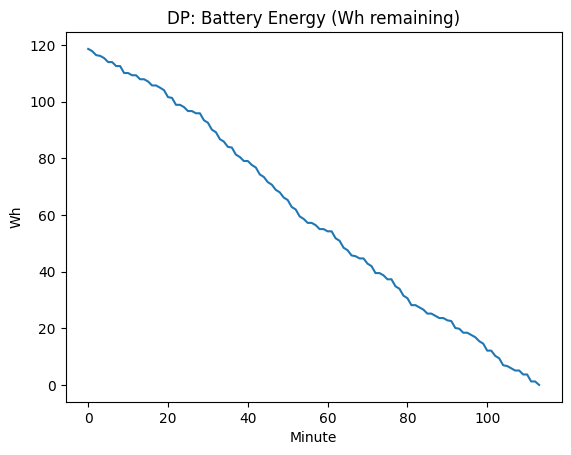

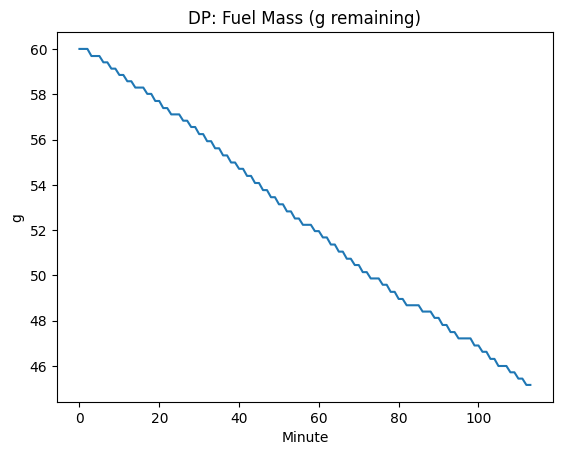

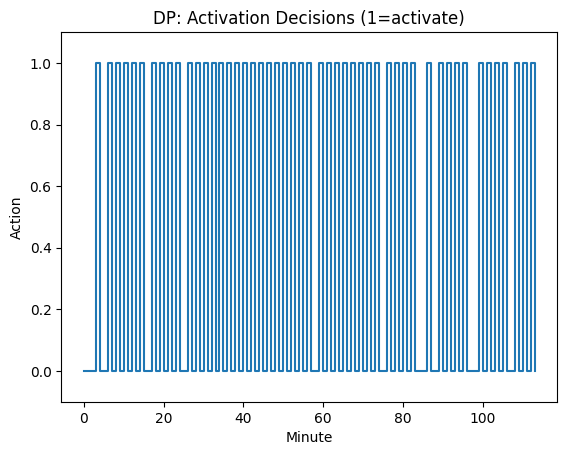

In [7]:
E_levels = np.linspace(0, E_batt_max, 61)
m_levels = np.linspace(0, m_fuel0, 61)
cool_levels = np.array([0, 1, 2])

def nearest_idx(val, grid):
    return int(np.argmin(np.abs(grid - val)))

V = np.zeros((T+1, len(E_levels), len(m_levels), len(cool_levels)), dtype=np.float32)
pi = np.zeros((T, len(E_levels), len(m_levels), len(cool_levels)), dtype=np.int8)

def dp_step(E, m, c, P, a):
    water_p = water_availability  # expected value approximation
    if c > 0 and a == 1:
        a = 0

    P_from_fc = 0.0
    m_used = 0.0
    c_next = max(0, c - 1)

    if a == 1 and m > 0 and water_p > 0:
        P_from_fc = min(P_activation_target, P_fc_max, P) * water_p
        e_elec = P_from_fc * dt_hr
        e_fuel_required = e_elec / max(1e-9, eta_fc)
        m_used = min(e_fuel_required / max(1e-9, e_fuel_wh_per_g), m)

        e_fuel_actual = m_used * e_fuel_wh_per_g
        e_elec_actual = e_fuel_actual * eta_fc
        P_from_fc = e_elec_actual / dt_hr
        m2 = m - m_used
        c_next = cooldown_after_activation
    else:
        m2 = m

    P_remaining = max(0.0, P - P_from_fc)
    e_needed = P_remaining * dt_hr
    e_from_batt = e_needed / max(1e-9, eta_batt)

    if E >= e_from_batt:
        E2 = E - e_from_batt
        unmet = 0.0
    else:
        unmet = e_needed - (E * eta_batt)
        E2 = 0.0

    c2 = max(0, c_next - 1) if c_next > 0 else 0
    return E2, m2, c2, unmet

for t in range(T-1, -1, -1):
    P = float(P_load[t])
    for iE, E in enumerate(E_levels):
        for im, m in enumerate(m_levels):
            for ic, c in enumerate(cool_levels):
                best_val, best_a = -1e9, 0
                for a in (0, 1):
                    E2, m2, c2, unmet = dp_step(E, m, int(c), P, a)
                    if unmet > 1e-9:
                        val = -1e6
                    else:
                        jE = nearest_idx(E2, E_levels)
                        jm = nearest_idx(m2, m_levels)
                        jc = nearest_idx(c2, cool_levels)
                        val = 1.0 + V[t+1, jE, jm, jc]
                    if val > best_val:
                        best_val, best_a = val, a
                V[t, iE, im, ic] = best_val
                pi[t, iE, im, ic] = best_a

def dp_policy(E_batt, m_fuel, cooldown, P, t):
    iE = nearest_idx(E_batt, E_levels)
    im = nearest_idx(m_fuel, m_levels)
    ic = nearest_idx(cooldown, cool_levels)
    if t >= len(pi):
        return 0
    return int(pi[t, iE, im, ic])

res_dp = simulate(P_load, dp_policy, water_p=water_availability)
print("DP runtime:", res_dp.runtime, "min")
plot_result(res_dp, "DP:")


## 7) MPC: Receding-horizon planning (beam search)


MPC runtime: 73 min


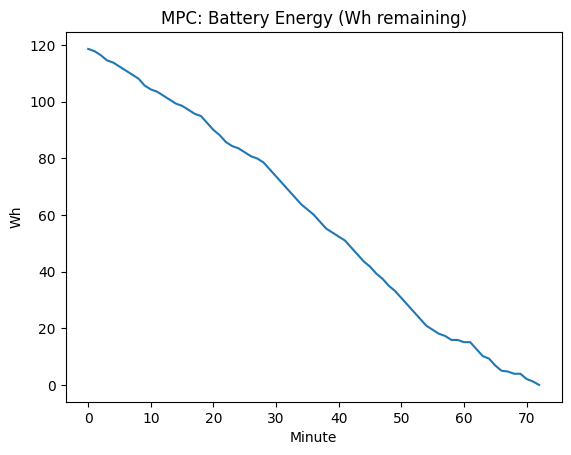

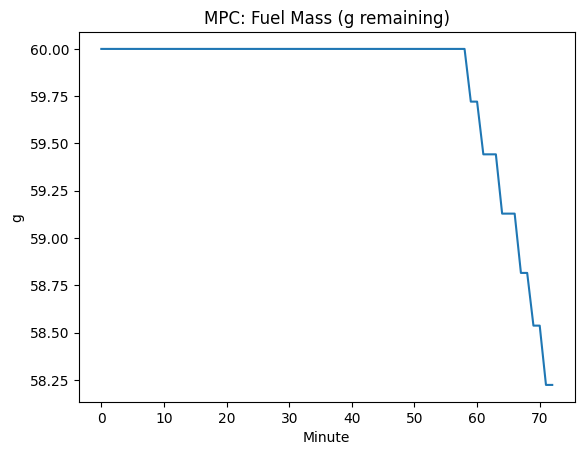

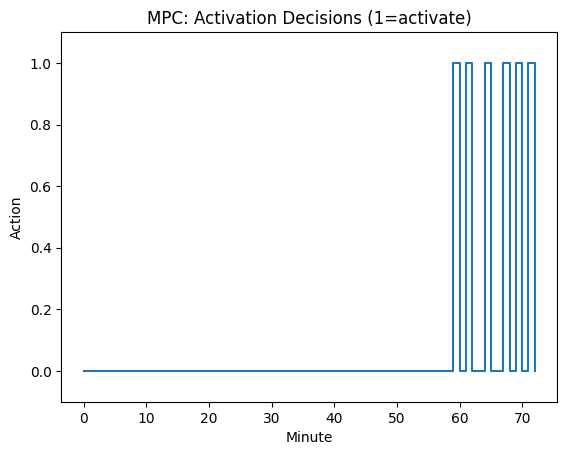

In [8]:
H = 12
K = 40

def score_sequence(E, m, c, t0, seq):
    E2, m2, c2 = E, m, c
    score = 0.0
    for k, a in enumerate(seq):
        t = t0 + k
        if t >= len(P_load):
            break
        P = float(P_load[t])
        E3, m3, c3, unmet, batt_out, fuel_out, a_used = step_dynamics(
            E2, m2, c2, P, a, water_p=water_availability
        )
        if unmet > 1e-9:
            score -= 1e6
            return score, E3, m3, c3
        score += 1.0
        score -= 0.02 * fuel_out
        if a_used == 1 and P < 70.0:
            score -= 0.3
        E2, m2, c2 = E3, m3, c3
    return score, E2, m2, c2

def mpc_policy(E_batt, m_fuel, cooldown, P, t):
    beam = [([], 0.0, E_batt, m_fuel, cooldown)]
    for depth in range(H):
        new_beam = []
        for seq, sc, E, m, c in beam:
            for a in (0, 1):
                sc2, E2, m2, c2 = score_sequence(E, m, c, t+len(seq), [a])
                new_beam.append((seq+[a], sc + sc2, E2, m2, c2))
        new_beam.sort(key=lambda x: x[1], reverse=True)
        beam = new_beam[:K]
    best_seq = beam[0][0] if beam else [0]
    return int(best_seq[0])

res_mpc = simulate(P_load, mpc_policy, water_p=water_availability)
print("MPC runtime:", res_mpc.runtime, "min")
plot_result(res_mpc, "MPC:")


## 8) Compare all controllers


Runtime (min):
  Baseline: 100
  RL      : 106
  DP      : 114
  MPC     : 73


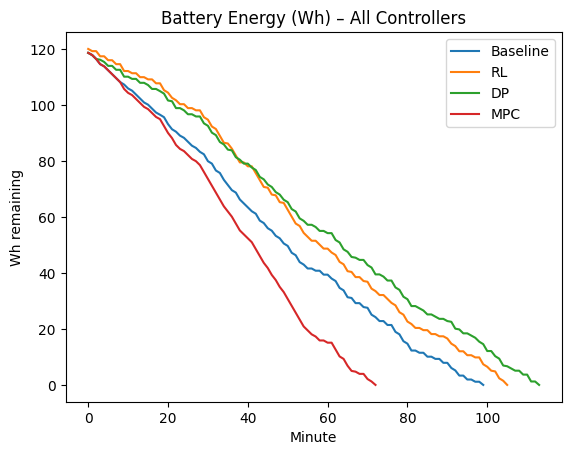

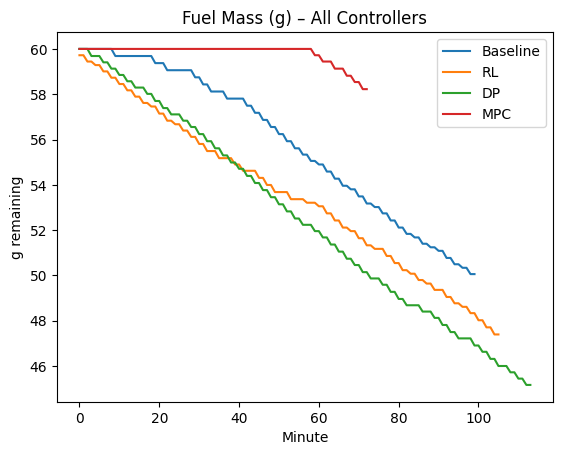

In [9]:
print("Runtime (min):")
print("  Baseline:", res_base.runtime)
print("  RL      :", res_rl.runtime)
print("  DP      :", res_dp.runtime)
print("  MPC     :", res_mpc.runtime)

plt.figure()
plt.plot(res_base.E_batt_trace, label="Baseline")
plt.plot(res_rl.E_batt_trace, label="RL")
plt.plot(res_dp.E_batt_trace, label="DP")
plt.plot(res_mpc.E_batt_trace, label="MPC")
plt.title("Battery Energy (Wh) – All Controllers")
plt.xlabel("Minute"); plt.ylabel("Wh remaining")
plt.legend()
plt.show()

plt.figure()
plt.plot(res_base.m_fuel_trace, label="Baseline")
plt.plot(res_rl.m_fuel_trace, label="RL")
plt.plot(res_dp.m_fuel_trace, label="DP")
plt.plot(res_mpc.m_fuel_trace, label="MPC")
plt.title("Fuel Mass (g) – All Controllers")
plt.xlabel("Minute"); plt.ylabel("g remaining")
plt.legend()
plt.show()
